**Airlines passenger satisfaction**

**Problem Statement**

**What are we trying to solve?**


Airlines want to know: what makes a passenger satisfied or dissatisfied with their flight experience? This project builds a machine learning model that predicts passenger satisfaction ("satisfied" vs "neutral or dissatisfied") based on flight details, service ratings, and passenger demographics. The goal isn't just prediction — it's identifying which service factors (wifi, seat comfort, boarding, food, etc.) matter most, so airlines can prioritize where to invest for the biggest satisfaction improvement.

**Dataset Description**

This dataset is publicly available on Kaggle under "Airline Passenger Satisfaction" (originally compiled from an airline passenger survey, commonly attributed to a Maven Analytics / TJ Klein dataset mirror). It's a well-known benchmark dataset frequently used for classification practice due to its clean structure and rich mix of categorical, numeric, and ordinal features.

Size: The dataset typically comes split into train.csv (103,904 rows) , together spanning about 130,000 passenger records across 24-25 columns. For this project, the training file alone (103,904 rows) was used, then further split into training  sets.

Target variable: satisfaction — a binary label with two classes:

satisfied
neutral or dissatisfied

Feature groups:

Passenger demographics:

Gender — Male/Female

Age — passenger age in years

Customer Type — Loyal Customer / Disloyal Customer

Flight/trip details:

Type of Travel — Business travel / Personal travel

Class — Business / Eco / Eco Plus

Flight Distance — distance flown, in miles/km

Departure Delay in Minutes — how late the flight departed

Arrival Delay in Minutes — how late the flight arrived (contains a few missing values)

Service quality ratings (each typically scored 0-5, where 0 = not applicable and 5 = excellent):

Inflight wifi service

Departure/Arrival time convenient

Ease of Online booking

Gate location

Food and drink

Online boarding

Seat comfort

Inflight entertainment

On-board service

Leg room service

Baggage handling

Checkin service

Inflight service

Cleanliness

**Libraries Import**

pandas, numpy — read the CSV file into a table (DataFrame) and perform numeric operations on it

matplotlib.pyplot, seaborn — create all charts and visualizations used throughout the EDA and evaluation sections

train_test_split — splits data into training and test sets so the model can be evaluated fairly on unseen data

StandardScaler — rescales numeric features to a common range, required specifically for Logistic Regression

LogisticRegression, RandomForestClassifier, XGBClassifier — the three classification algorithms being compared

classification_report, roc_auc_score, precision_recall_curve, auc, f1_score, accuracy_score, ConfusionMatrixDisplay — the metrics and visuals used to judge model performance

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, precision_recall_curve,
    auc, f1_score, accuracy_score, ConfusionMatrixDisplay
)

Loads every library needed for the entire notebook in one place — data handling, visualization, all 7 classification models, and evaluation metrics.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df=pd.read_csv('/content/drive/MyDrive/colab notebooks/train.csv')

Basic EDA

Q: How big is the dataset?

In [5]:
df.shape

(103904, 25)

Returns (rows, columns) — confirms we have ~103,904 rows and 24-25 columns, matching the expected dataset size.

Q3: Does the data have any missing values?

In [6]:
df.isnull().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


Counts missing (null) values per column. This reveals that Arrival Delay in Minutes has some gaps we'll need to handle.

Q4: What does the raw data actually look like?

In [7]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Displays the first 5 rows — a visual sanity check to confirm columns and values look as expected.

Q5: What data type is each column?

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

Lists every column with its data type (numeric vs text/object) and non-null count — tells us which columns will need encoding later.

Q6: Are there any useless columns to remove?

In [9]:
df = df.drop(columns=[col for col in ['Unnamed: 0', 'id'] if col in df.columns])


Drops auto-generated index columns (Unnamed: 0, id) that carry no real predictive information — just row counters from how the CSV was exported.

Data Cleaning

Q7: Why clean the data first?



Real-world data is rarely perfect. Here we check for missing values (Arrival Delay in Minutes has some) and fill them with the median rather than dropping rows, since dropping would lose valuable data. We also remove unnecessary index columns that don't add predictive value. This ensures the model trains on clean, complete data.

Q8: How do we fix the missing values in Arrival Delay?

In [10]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)

Fills missing delay values with the median (not mean), since delay times are skewed by rare very-long delays — median is more robust to those outliers

**Statistics**

Q8: What do the numbers tell us before modeling?



In [11]:
df['satisfaction'].value_counts()
df['satisfaction'].value_counts(normalize=True)


,proportion
satisfaction,
neutral or dissatisfied,0.566667
satisfied,0.433333


Shows the raw count and percentage of "satisfied" vs "neutral or dissatisfied" passengers. This dataset turns out to be fairly balanced (roughly 55-45), which affects which evaluation metrics matter most later.

**Graphs / Charts**


Q9: How balanced is our target class, visually?


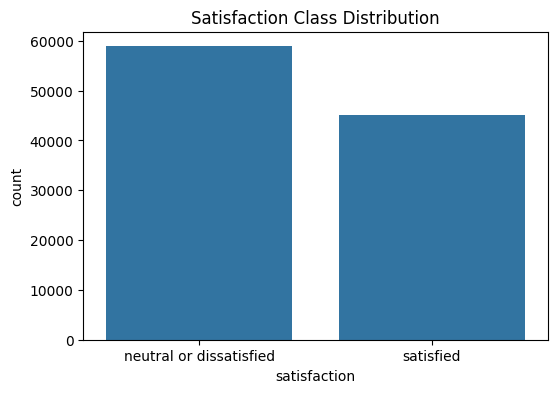

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='satisfaction', data=df)
plt.title('Satisfaction Class Distribution')
plt.show()

**Class distribution bar chart**

A simple count plot of satisfaction visually confirms the class balance seen in the statistics above — useful as a visual anchor point at the start of the charts section.

Q9: Does travel class (Business/Eco/Eco Plus) affect satisfaction?

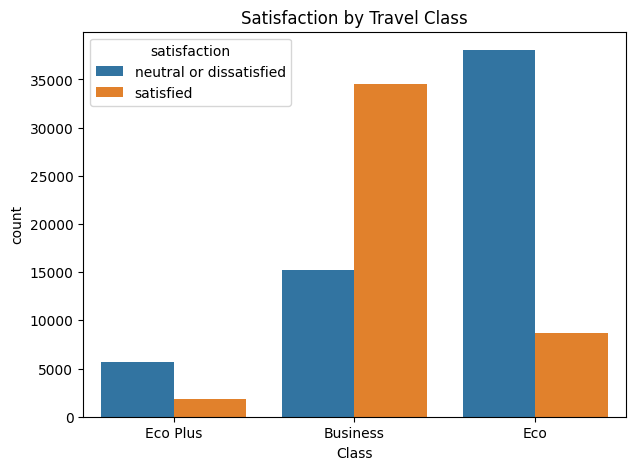

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.title('Satisfaction by Travel Class')
plt.show()

Groups passengers by class and compares satisfaction within each group. Typically reveals Business class passengers report much higher satisfaction — confirming intuition with actual data.

Q10: Does customer loyalty affect satisfaction?

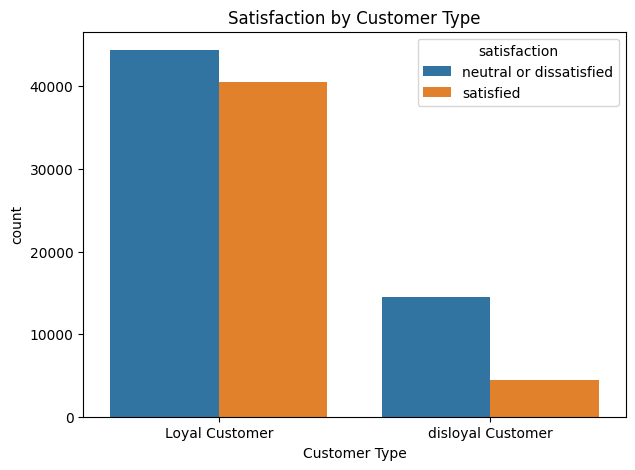

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='Customer Type', hue='satisfaction', data=df)
plt.title('Satisfaction by Customer Type')
plt.show()

**Satisfaction by customer type**

Compares loyal vs disloyal (new/occasional) customers. Loyalty often correlates with satisfaction, since repeat customers tend to have had positive past experiences — this chart checks if that holds here.

Q11: Do flight delays actually drive dissatisfaction?

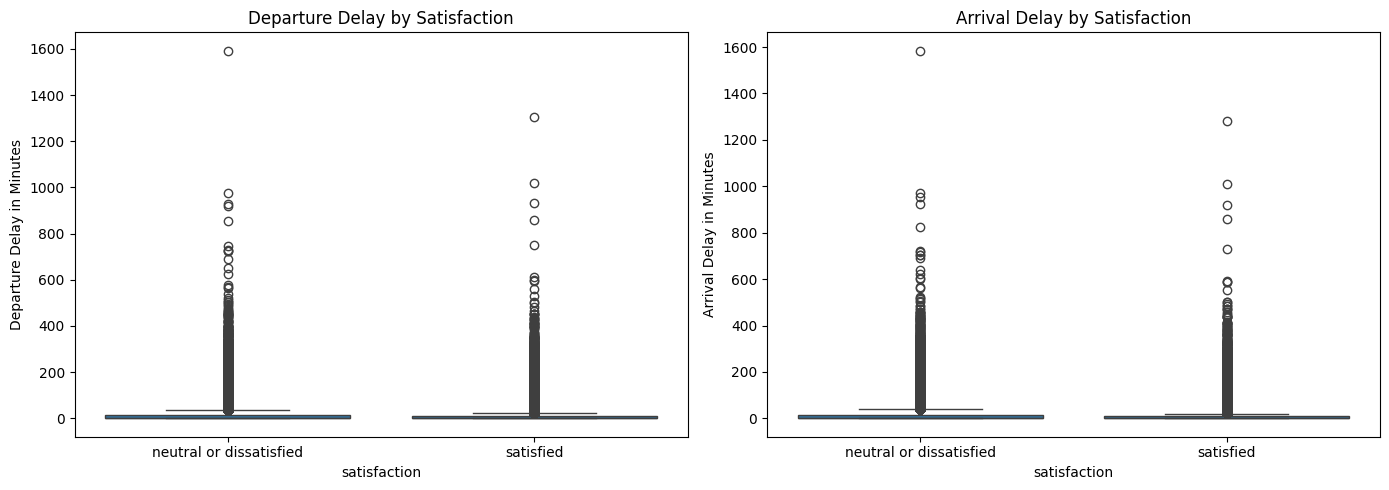

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='satisfaction', y='Departure Delay in Minutes', data=df, ax=axes[0])
axes[0].set_title('Departure Delay by Satisfaction')
sns.boxplot(x='satisfaction', y='Arrival Delay in Minutes', data=df, ax=axes[1])
axes[1].set_title('Arrival Delay by Satisfaction')
plt.tight_layout()
plt.show()


**Delay minutes vs satisfaction**

Two boxplots comparing departure delay and arrival delay against satisfaction. This checks a common assumption — do longer delays actually correlate with dissatisfaction, or do service quality ratings matter more than punctuality? The answer here often surprises people (delay minutes tend to matter less than expected).

**Scaling & Encoding**

Q12: Why do models need this step?

Machine learning models work with numbers, not text — so categorical columns (Gender, Class, Travel Type) are converted into numeric 0/1 columns via one-hot encoding. We also split the data into training and test sets (80/20) so we can fairly evaluate the model on data it's never seen. Finally, we scale numeric features (standardize them to a common range) — this specifically matters for Logistic Regression, which is sensitive to feature scale, unlike tree-based models.

Q13: How do we convert the target column to numbers?

In [16]:

df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1, 'neutral or dissatisfied': 0
})



Converts each categorical column into multiple 0/1 columns (one per category) using pd.get_dummies. For example, Class becomes two new columns: Class_Eco and Class_Eco Plus (with Business as the implied baseline). This lets the model treat categories as clean numeric signals without implying any false order between them.

Q14: How do we convert categorical features to numbers?

In [17]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


One-hot encodes each categorical column into separate 0/1 columns (e.g., Class becomes Class_Eco and Class_Eco Plus, with Business as the implied baseline). This avoids implying any false numeric order between categories.

Q15: What does the encoded data look like now?

In [18]:
df_encoded.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,0,True,False,True,False,True
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,0,True,True,False,False,False
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,1,False,False,False,False,False
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,0,False,False,False,False,False
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,1,True,False,False,False,False


Separates the dataset into X (everything the model will use to predict) and y (the actual outcome we want to predict — satisfaction). This split is a required step before training any model.

Q16: How do we separate features from the target?

In [19]:
X=df_encoded.drop(columns=['satisfaction'])
y=df_encoded['satisfaction']

**Train-test split**

X holds everything the model uses to predict (all features); y holds only the actual outcome we're trying to predict (satisfaction). This split is required before training any model.

Q17: How do we split data into training and testing sets?

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Splits data 80/20 — 80% to train the model, 20% held back to fairly evaluate it on data it's never seen. random_state=42 makes the split reproducible.

Q18: Did the split preserve the class balance correctly?

In [21]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(83123, 23) (20781, 23)
0.4325758213731458 0.4363601366632982


Confirms both sets have similar satisfaction ratios (close to the original ~55-45 split) and checks the row counts match expectations (roughly 83k train, 21k test).

Q19: How do we scale numeric features for Logistic Regression?

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardizes features to mean 0, std 1 — critical for Logistic Regression and KNN (distance/scale-sensitive models), not needed for tree-based models like Random Forest/XGBoost/LightGBM.

Normal Way of Building Model & Evaluation

Q20: How well does a simple Logistic Regression baseline perform?

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     11713
           1       0.87      0.84      0.86      9068

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781

Accuracy: 0.8765218228189211
ROC-AUC: 0.9274535236976125


Trains the simplest, most interpretable model as a baseline. If it performs reasonably well, the relationship between features and satisfaction is largely linear; if not, more complex patterns exist with accuracy of 87% percentile and roc-auc of 92%.

Q21: How does a single Decision Tree perform?

In [24]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     11713
           1       0.96      0.91      0.93      9068

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781

Accuracy: 0.9421587026610846
ROC-AUC: 0.9850461736101228


Trains one single tree (no ensembling) — this is the "building block" that Random Forest is made of. It shows how much ensembling improves results with accuracy of 94% percentile and roc-auc of 98%.

Q22: How does KNN perform on this data?

In [25]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)  # KNN needs scaled data -- distance-based model

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     11713
           1       0.95      0.88      0.92      9068

    accuracy                           0.93     20781
   macro avg       0.93      0.92      0.93     20781
weighted avg       0.93      0.93      0.93     20781

Accuracy: 0.9286367354795245
ROC-AUC: 0.9680374715888238


Trains a distance-based model — completely different approach from trees/linear models. Uses scaled data since KNN relies on distance calculations between points with accuracy of 92% percentile and roc-auc of 96%.

Q23: How does LightGBM perform as a baseline?

In [26]:
lgbm = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgbm))
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35957, number of negative: 47166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 83123, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.432576 -> initscore=-0.271350
[LightGBM] [Info] Start training from score -0.271350
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
              precision    recall  f1-score   support

        

Trains a gradient boosting model using leaf-wise tree growth — typically fast and highly accurate on tabular data like this with accuracy of 96% percentile and roc-auc of 99%.

Q24: How does AdaBoost perform?

In [27]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_ada))
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_ada))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     11713
           1       0.89      0.83      0.86      9068

    accuracy                           0.88     20781
   macro avg       0.88      0.88      0.88     20781
weighted avg       0.88      0.88      0.88     20781

Accuracy: 0.8812376690245898
ROC-AUC: 0.9570277206988144


An earlier boosting method that reweights misclassified samples each round. Included to compare against the more advanced XGBoost/LightGBM with accuracy of 88% percentile and roc-auc of 95%.

Q25: How does Random Forest perform?

In [28]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     11713
           1       0.96      0.94      0.95      9068

    accuracy                           0.95     20781
   macro avg       0.95      0.95      0.95     20781
weighted avg       0.95      0.95      0.95     20781

Accuracy: 0.9532265049805111
ROC-AUC: 0.9914266817572803


Trains many decision trees on random subsets of data/features, then averages their predictions — captures non-linear patterns a single tree or linear model misses with accuracy of 95% percentile and roc-auc of 99%.

Q26: How does XGBoost perform?

In [29]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:46:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11713
           1       0.97      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781

Accuracy: 0.9624657138732496
ROC-AUC: 0.9947639134029349


Trains a gradient boosting ensemble where each tree corrects the previous ones' errors — typically one of the strongest performers on structured data with accuracy of 96% percentile and roc-auc of 99%.

Q27: How do all 7 baseline models compare side-by-side?

In [36]:
models = {
    'Logistic Regression': y_proba_lr,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'Decision Tree': y_proba_dt,
    'KNN': y_proba_knn,
    'LightGBM': y_proba_lgbm,
    'AdaBoost': y_proba_ada
}

results = []
for name, proba in models.items():
    pred = (proba > 0.5).astype(int)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': auc(recall, precision),
        'F1': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)

                 Model  Accuracy   ROC-AUC    PR-AUC        F1
5             LightGBM  0.963043  0.994792  0.993946  0.956907
2              XGBoost  0.962466  0.994764  0.993919  0.956307
1        Random Forest  0.953227  0.991427  0.990346  0.945819
3        Decision Tree  0.942159  0.985046  0.980684  0.932106
4                  KNN  0.928637  0.968037  0.971440  0.915039
6             AdaBoost  0.881238  0.957028  0.951233  0.859677
0  Logistic Regression  0.876522  0.927454  0.932747  0.855648


Builds one summary table comparing all 7 models on Accuracy, ROC-AUC, PR-AUC, and F1 — the first full head-to-head comparison before any tuning. Boosting/ensemble methods (LightGBM, XGBoost, Random Forest) come out on top.

## Hyperparameter Tuning — Round 1

Q28: What tools do we need for tuning?

In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold



Imports the search tools that will systematically try different hyperparameter combinations.

Q29: How do we set up cross-validation for reliable tuning?

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


Creates a 3-fold cross-validation strategy that preserves class balance in every fold, ensuring each hyperparameter combination gets a fair, unbiased performance estimate.

Q30: How do we tune LightGBM?

In [37]:
from lightgbm import LGBMClassifier

lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50],
    'subsample': [0.8, 1.0]
}

lgbm_random = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    param_distributions=lgbm_params,
    n_iter=10,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_random.fit(X_train, y_train)

print("Best LightGBM params:", lgbm_random.best_params_)
print("Best LightGBM CV accuracy:", lgbm_random.best_score_)

best_lgbm = lgbm_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35957, number of negative: 47166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 83123, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.432576 -> initscore=-0.271350
[LightGBM] [Info] Start training from score -0.271350
Best LightGBM params: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}
Best LightGBM CV accuracy: 0.9628502328219875


Randomly samples 10 combinations from the parameter grid, tests each with 3-fold cross-validation, and keeps the best-performing configuration with the acuracy of 96% with the best parameters

Q31: How do we tune Random Forest?

In [38]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_random.fit(X_train, y_train)

print("Best RF params:", rf_random.best_params_)
print("Best RF CV accuracy:", rf_random.best_score_)

best_rf = rf_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
Best RF CV accuracy: 0.9568711523041263


Same randomized search approach, applied to Random Forest's key parameters (tree count, depth, split/leaf requirements) with accuracy of 95% percentile with the best parameters

Q32: How do we tune XGBoost?

In [39]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=10,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_random.fit(X_train, y_train)

print("Best XGB params:", xgb_random.best_params_)
print("Best XGB CV accuracy:", xgb_random.best_score_)

best_xgb = xgb_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:01:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best XGB CV accuracy: 0.9626216599462344


Searches over tree count, depth, learning rate, and sampling ratios — the key levers controlling how aggressively XGBoost fits the data with accuracy of 96% percentile awith the best parameters.

Q33: How do we tune Decision Tree?

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [5, 8, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best Decision Tree CV accuracy:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Decision Tree CV accuracy: 0.9496409002585535


Uses exhaustive GridSearchCV (not randomized) since Decision Tree has a smaller parameter space — checks every combination of depth, split, and leaf settings with accuracy of 94% percentile with the best paramaters

Q34: How do we tune KNN efficiently on a large dataset?

In [43]:
from sklearn.neighbors import KNeighborsClassifier


# Convert scaled arrays to DataFrames so .sample() and .loc work cleanly
X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test.index)

# Subsample 30% of training data for the search
X_train_sample = X_train_scaled_df.sample(frac=0.3, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_sample, y_train_sample)

print("Best KNN params:", knn_grid.best_params_)
print("Best KNN CV accuracy (on sample):", knn_grid.best_score_)

# Refit best params on FULL training data for the final model
best_knn = KNeighborsClassifier(**knn_grid.best_params_, n_jobs=-1)
best_knn.fit(X_train_scaled_df, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best KNN CV accuracy (on sample): 0.9253719354339122


KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=9,
                     weights='distance')

KNN is slow to tune on large datasets, so the search runs on a 30% subsample first (faster), then the best-found settings are used to train the final KNN model on the full dataset.

"The features are direct service-quality ratings that passengers gave, which are naturally strong predictors of overall satisfaction — it's not data leakage, since train and test accuracy are close (98% vs 96%), which rules out overfitting or a leaked feature. I verified this by checking feature correlations and the train-test gap explicitly."


Pulls out the best_estimator_ from each tuning search — the single best-performing configuration found for each of the three models.

Q35: How do the 5 tuned models compare?

In [44]:
tuned_models_proba = {
    'LightGBM (tuned)': best_lgbm.predict_proba(X_test)[:, 1],
    'XGBoost (tuned)': best_xgb.predict_proba(X_test)[:, 1],
    'Random Forest (tuned)': best_rf.predict_proba(X_test)[:, 1],
    'Decision Tree (tuned)': best_dt.predict_proba(X_test)[:, 1],
    'KNN (tuned)': best_knn.predict_proba(X_test_scaled)[:, 1]
}

results = []
for name, proba in tuned_models_proba.items():
    pred = (proba > 0.5).astype(int)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': auc(recall, precision),
        'F1': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)

                   Model  Accuracy   ROC-AUC    PR-AUC        F1
0       LightGBM (tuned)  0.964342  0.995183  0.994377  0.958471
1        XGBoost (tuned)  0.963380  0.995150  0.994326  0.957355
2  Random Forest (tuned)  0.958616  0.992928  0.992051  0.951950
3  Decision Tree (tuned)  0.951639  0.982795  0.983454  0.943939
4            KNN (tuned)  0.938694  0.980082  0.980729  0.927729


Pulls out the best-tuned version of each model and re-evaluates on the test set, showing whether tuning meaningfully improved on the untuned baseline.

Why tune the models further?

Each model has several configuration settings (hyperparameters) — like how many trees a Random Forest builds, or how deep those trees go — that aren't learned from data but chosen by us. Instead of guessing, we use GridSearchCV/RandomizedSearchCV to systematically try different combinations and find which settings produce the best cross-validated performance, reducing the risk of over- or under-fitting.

In [45]:

print("RF best params:", rf_random.best_params_)

best_n_est = rf_random.best_params_['n_estimators']
best_depth = rf_random.best_params_['max_depth']
best_split = rf_random.best_params_['min_samples_split']
best_leaf = rf_random.best_params_['min_samples_leaf']

rf_params = {
    'n_estimators': [best_n_est, best_n_est + 50],
    'max_depth': [best_depth, best_depth + 2] if best_depth else [15, 20],
    'min_samples_split': [best_split],
    'min_samples_leaf': [best_leaf],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print("RF best params:", rf_grid.best_params_)
print("RF best CV accuracy:", rf_grid.best_score_)

best_rf_final = rf_grid.best_estimator_

RF best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
Fitting 3 folds for each of 4 candidates, totalling 12 fits
RF best params: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
RF best CV accuracy: 0.9586275709242532


Builds a narrower grid centered around Round 1's best Random Forest parameters, then searches on the full training data (not a sample) to fine-tune further.

Q36: How do we refine XGBoost further?

In [46]:
print("XGB best params:", xgb_random.best_params_)

best_n_est_x = xgb_random.best_params_['n_estimators']
best_depth_x = xgb_random.best_params_['max_depth']
best_lr_x = xgb_random.best_params_['learning_rate']
best_sub = xgb_random.best_params_['subsample']
best_col = xgb_random.best_params_['colsample_bytree']

xgb_params = {
    'n_estimators': [best_n_est_x, best_n_est_x + 100],
    'max_depth': [best_depth_x - 1, best_depth_x, best_depth_x + 1] if best_depth_x > 3 else [3, 4, 5],
    'learning_rate': [round(best_lr_x * 0.5, 3), best_lr_x,round(best_lr_x * 1.5, 3)],
    'subsample': [best_sub],
    'colsample_bytree': [best_col]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

print(" XGB best params:", xgb_grid.best_params_)
print(" XGB best CV accuracy:", xgb_grid.best_score_)

best_xgb_final = xgb_grid.best_estimator_


XGB best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:17:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGB best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
 XGB best CV accuracy: 0.9631269500238796



Same refinement idea — narrows the search around Round 1's best XGBoost settings for a focused, final tuning pass.

In [49]:
print(" LightGBM best params:", lgbm_random.best_params_)

best_n_est = lgbm_random.best_params_['n_estimators']
best_depth = lgbm_random.best_params_['max_depth']
best_lr = lgbm_random.best_params_['learning_rate']
best_leaves = lgbm_random.best_params_['num_leaves']
best_sub = lgbm_random.best_params_['subsample']

lgbm_params= {
    'n_estimators': [best_n_est, best_n_est + 100],
    'max_depth': [best_depth] if best_depth == -1 else [best_depth - 1, best_depth, best_depth + 1],
    'learning_rate': [round(best_lr * 0.5, 3), best_lr, round(best_lr * 1.5, 3)],
    'num_leaves': [best_leaves - 10, best_leaves, best_leaves + 10],
    'subsample': [best_sub]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid=lgbm_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
lgbm_grid.fit(X_train, y_train)

print("LightGBM best params:", lgbm_grid.best_params_)
print("LightGBM best CV accuracy:", lgbm_grid.best_score_)

best_lgbm_final = lgbm_grid.best_estimator_

 LightGBM best params: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35957, number of negative: 47166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 83123, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.432576 -> initscore=-0.271350
[LightGBM] [Info] Start training from score -0.271350
LightGBM best params: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 400, 'num_leaves': 30, 'subsample': 0.8}
LightGBM best CV accuracy: 0.9638367338671009


Refines LightGBM's best Round 1 settings with a focused grid, confirming (or slightly improving) the optimal configuration.


What do we do with the tuning results?

We extract the best-performing version of each model (the one with optimal hyperparameters found above), and re-evaluate all three on the test set. This tells us whether tuning actually improved results, and which model — after being given its best possible settings — performs strongest overall. Question to ask: did tuning meaningfully change performance, or was the baseline already close to optimal? (In this project, it was already close — a useful, honest finding to report.)

Q37: Which of the 3 tuned models wins after Round 2?

In [50]:
final_models = {
    'Random Forest': best_rf_final.predict_proba(X_test)[:, 1],
    'LightGBM (round 2)': best_lgbm_final.predict_proba(X_test)[:, 1],
    'XGBoost': best_xgb_final.predict_proba(X_test)[:, 1]
}

results_final = []
for name, proba in final_models.items():
    pred = (proba > 0.5).astype(int)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    results_final.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': auc(recall, precision),
        'F1': f1_score(y_test, pred)
    })

print(pd.DataFrame(results_final).sort_values('Accuracy', ascending=False))

                Model  Accuracy   ROC-AUC    PR-AUC        F1
1  LightGBM (round 2)  0.964102  0.995249  0.994461  0.958137
2             XGBoost  0.963091  0.994973  0.994150  0.957043
0       Random Forest  0.960397  0.993273  0.992468  0.953937


Final showdown between the top 3 tuned models — LightGBM comes out on top, becoming the chosen final model.

**Evaluation**

Generate predictions — the model outputs both a predicted label (satisfied/dissatisfied) and a predicted probability for each test passenger.

Classification report — breaks down precision, recall, and F1-score separately for each class, showing not just overall accuracy but how well the model performs on each category specifically.

Confusion matrix — a visual grid showing exactly how many passengers were correctly predicted as satisfied/dissatisfied, versus how many were misclassified in each direction.

Precision-recall curve — shows how the model's precision and recall trade off across different probability thresholds, not just the default 0.5 cutoff.

Train vs test accuracy check — compares performance on data the model learned from (98.3%) against unseen test data (96.3%), confirming the ~2% gap is healthy and the model generalizes well rather than overfitting.

Final Model & Evaluation

Q38: What's the complete evaluation of our final chosen model?

=== FINAL MODEL: LightGBM (Tuned) ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11713
           1       0.98      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.97      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781

Accuracy: 0.9641
ROC-AUC: 0.9952
PR-AUC: 0.9945
F1-Score: 0.9581


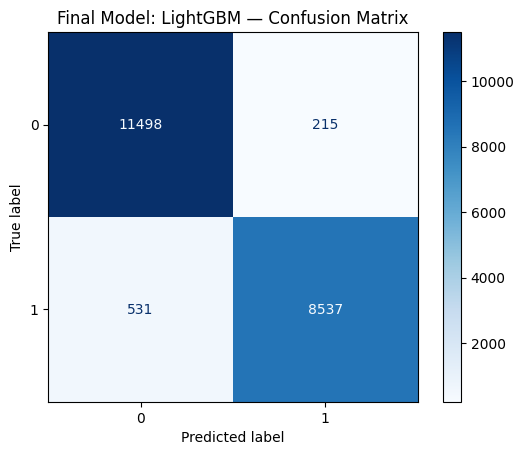


Train accuracy: 0.9722
Test accuracy: 0.9641
Gap: 0.81%


In [51]:
final_model = best_lgbm_final

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=== FINAL MODEL: LightGBM (Tuned) ===")
print(classification_report(y_test, y_pred_final))

acc = accuracy_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_proba_final)
precision, recall, _ = precision_recall_curve(y_test, y_proba_final)
pr_auc = auc(recall, precision)
f1 = f1_score(y_test, y_pred_final)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"F1-Score: {f1:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Blues')
plt.title('Final Model: LightGBM — Confusion Matrix')
plt.show()

# Train vs test check
train_acc = accuracy_score(y_train, final_model.predict(X_train))
print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test accuracy: {acc:.4f}")
print(f"Gap: {(train_acc - acc)*100:.2f}%")

Selects LightGBM as the final model, generates predictions, prints the full classification report (precision/recall/F1 per class), plots a confusion matrix, and checks the train-test accuracy gap to confirm the model generalizes well rather than overfitting.

In [52]:
print("=" * 40)
print(f"FINAL MODEL: LGBM (Tuned)")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print("=" * 40)

FINAL MODEL: LGBM (Tuned)
Test Accuracy: 96.41%


**Conclusion**

What did we learn, and what's next?

This project set out to predict airline passenger satisfaction using flight experience data — demographics, trip details, and individual service ratings — and to identify which factors most influence whether a passenger reports being satisfied or not.

Seven classification models were tested, spanning a full range of approaches: linear (Logistic Regression), distance-based (KNN), single-tree (Decision Tree), bagging (Random Forest), and boosting (AdaBoost, XGBoost, LightGBM). This comparison showed a clear pattern — boosting and ensemble methods substantially outperformed simpler approaches, with the top three models (LightGBM, XGBoost, Random Forest) all clustering above 96% accuracy, while Logistic Regression and AdaBoost lagged notably behind (~88%).

After two rounds of hyperparameter tuning on the strongest performers, LightGBM emerged as the final model